In [1]:
import sys
import os
# liset_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '../liset_tk'))
curr_path=os.getcwd()
project_dir=os.path.join(curr_path, os.pardir, os.pardir)

sys.path.insert(0, project_dir)

# from liset_tk.liset_aux import ripples_std, middle
from liset_tk.signal_aid import bandpass_filter,highpass_filter

from extract_Nripples.utils_encoding import *
import matplotlib.pyplot as plt
# from liset_tk import liset_tk
from liset_tk.liset_paper import liset_paper as liset_tk

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from liset_tk.signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns
from utils import *

In [2]:
parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
print("Available datasets:")
for i, dataset in enumerate(datasets):
    print(f"{i}: {dataset}")
print()
dataset=int(input("Dataset to process: "))
# dataset=3
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")

Available datasets:
0: Amigo2_2019-07-11_11-57-07
1: Dlx1_2021-02-12_12-46-54
2: Som2_2019-07-24_12-01-49
3: Thy7-2020-11-11_16-05-00

Processing dataset: Som2_2019-07-24_12-01-49


In [3]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples=liset.ripples_GT

In [4]:
downsample_factor=1
liset_data=liset.data
bandpass=(100,250)


# downsampled_liset=decimation_downsampling(channel_filtered,downsample_factor)
ripples_ds=ripples//downsample_factor

In [38]:
def plot_raw_filtered_signal(liset, channels, bandpass, window, filter=False,
                             downsample_factor=1, offset=2, subwindow=None, ripples=None, label=True):
    """
    Plots raw and filtered signals for selected channels with vertical offset.

    Parameters:
    - liset: original data object with `.data` and `.fs` attributes
    - filtered_liset: precomputed filtered data, same shape as liset.data
    - channels: list of channel indices to plot
    - bandpass: tuple of (low, high) frequencies for filtering
    - window: tuple (start_sec, end_sec)
    - filter: whether to apply bandpass filter to liset.data directly
    - downsample_factor: factor to downsample by
    - offset: vertical spacing between channel traces
    - subwindow: optional subwindow in seconds (e.g. (1,2)) inside the main window
    - ripples: optional list/array of ripple events (start_idx, end_idx)
    - spikes: whether to plot spikes
    - up_down: dict with 'up' and 'down' arrays of spike indices
    - both: whether to plot both filtered and unfiltered together
    - label: whether to include legend and title
    """

    fs = liset.fs
    fs_ds = fs // downsample_factor
    start_window, end_window = (np.array(window) * fs_ds).astype(int)

    # Raw and filtered data slices
    liset_data = liset.data[::downsample_factor]
    if filter:
        filtered_liset = np.zeros_like(liset_data)
        for ch in range(liset_data.shape[1]):
            filtered_liset[:, ch] = bandpass_filter(liset_data[:, ch], bandpass=bandpass, fs=fs)

    window = liset_data[start_window:end_window, :] if not filter else filtered_liset[start_window:end_window, :]

    # Subwindow slicing
    if subwindow:
        sub_start, sub_end = (np.array(subwindow) * fs_ds).astype(int)
        window = window[sub_start:sub_end, :]
        start_window += sub_start
        end_window = start_window + (sub_end - sub_start)

    time = np.linspace(0, (end_window - start_window) / fs_ds, window.shape[0])

    # Plotting
    fig, ax = plt.subplots(figsize=(14, 6))
    label
    for i, ch in enumerate(channels):
        offset_val = i * offset
        ax.plot(time, window[:, ch] + offset_val, lw=1.5)

    # Ripples
    if ripples is not None:
        for ripple_start, ripple_end in ripples:
            if ripple_end >= start_window and ripple_start <= end_window:
                ripple_start_t = (ripple_start - start_window) / fs_ds
                ripple_end_t = (ripple_end - start_window) / fs_ds
                ax.axvspan(ripple_start_t, ripple_end_t, color='yellow', alpha=0.3)
                
    # ax.set_xlabel("Time (s)")
    # ax.set_ylabel("Amplitude + Offset")
    ax.set_xlim(time[0], time[-1])
    ax.set_ylim(-offset*3, offset * (len(channels) + 1))
    # ax.set_title("Raw vs Filtered Signal ({} channels)".format(len(channels)) if label else "")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)
    # Remove ticks
    # ax.set_xticks([])
    # ax.set_yticks([])
    # if label:
    #     legend_elements = [
    #         Line2D([0], [0], color='black', lw=2, label='Original Signal'),
    #         Line2D([0], [0], color='green', lw=2, linestyle="--", label='Filtered Signal'),
    #         Line2D([0], [0], color='gold', lw=6, alpha=0.3, label='Ripples'),
    #     ]
    #     ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()
    return fig, ax


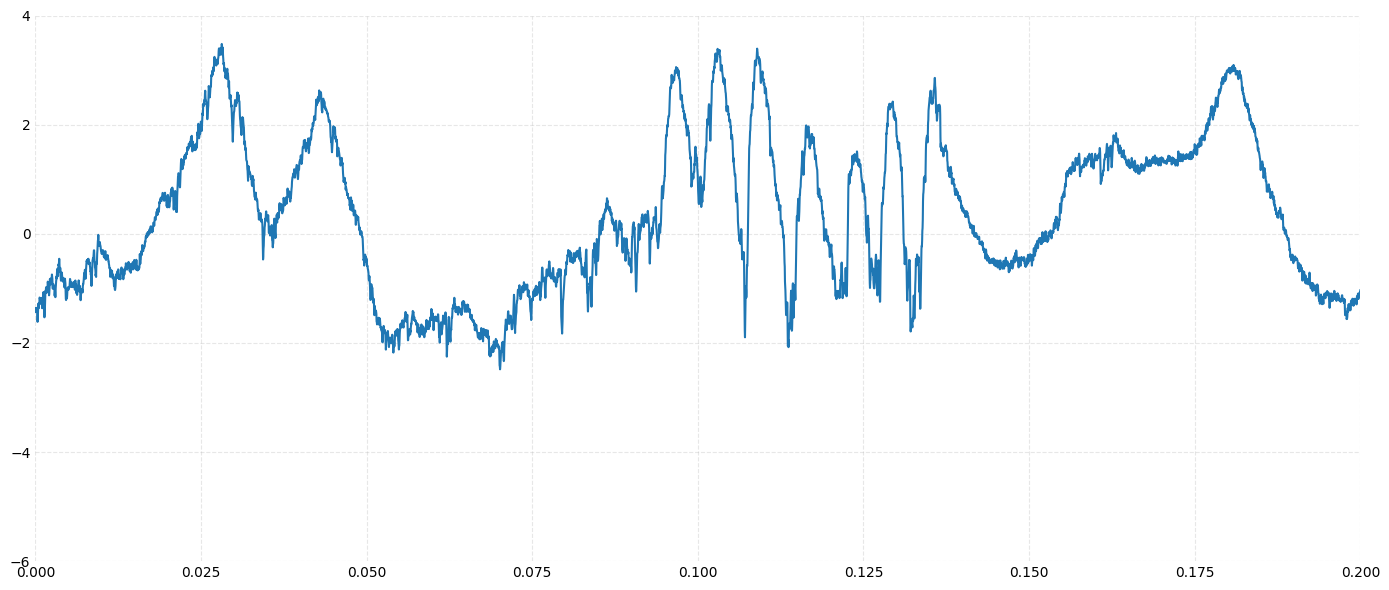

In [67]:
window=np.array([60,70]) # seconds
channels=range(8)
channels=[1]
subwindow=[6.3,6.5]
fig,ax=plot_raw_filtered_signal(liset, channels, bandpass, window, filter=False,
                             downsample_factor=1, offset=2, subwindow=subwindow, ripples=None, label=True)# Save to file
save_fig = os.path.join(os.getcwd(), "pngs")
os.makedirs(save_fig, exist_ok=True)
# filename= os.path.join(save_fig, f"so_unfiltered.png")
# fig.savefig(filename, dpi=300, bbox_inches='tight')

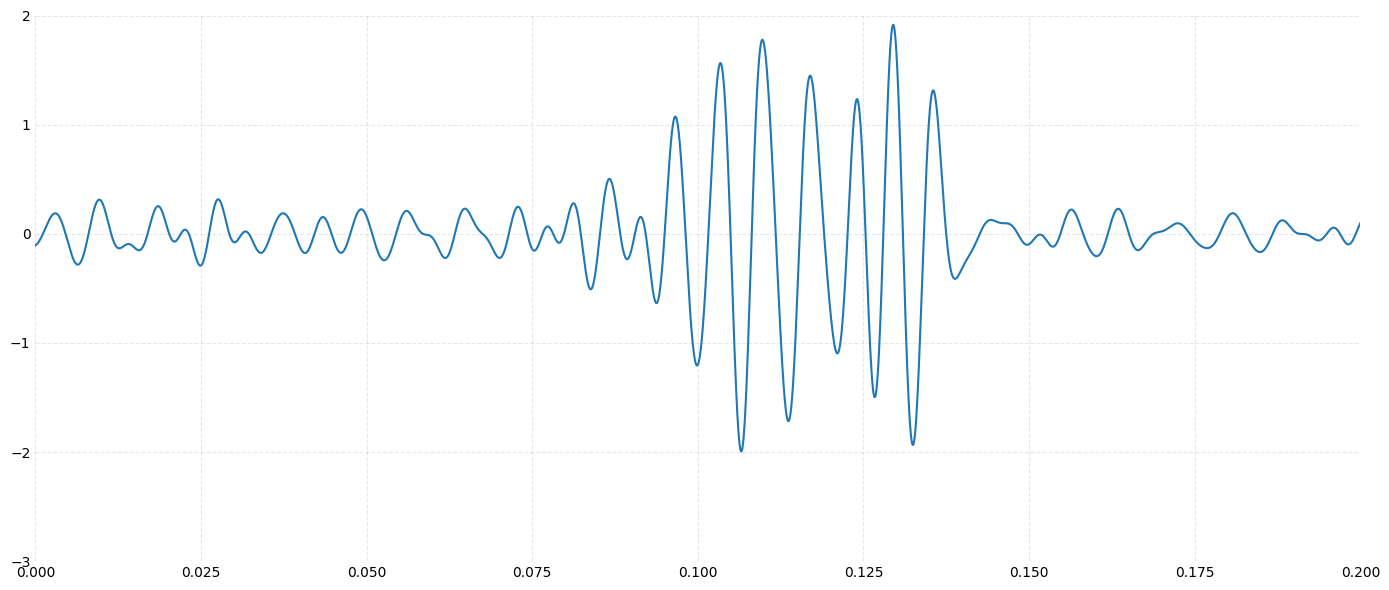

In [68]:
window=np.array([60,70]) # seconds
channels=range(8)
channels=[1]
subwindow=[6.3,6.5]
fig,ax=plot_raw_filtered_signal(liset, channels, bandpass, window, filter=True,
                             downsample_factor=1, offset=1, subwindow=subwindow, ripples=None, label=True)# Save to file
save_fig = os.path.join(os.getcwd(), "pngs")
os.makedirs(save_fig, exist_ok=True)
# filename= os.path.join(save_fig, f"so_filtered.png")
# fig.savefig(filename, dpi=300, bbox_inches='tight')